In [1]:
import os
import json
import pandas as pd
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from utils import safe_open_json, load_metrics_df

In [2]:
# ============================================================================
# PUBLICATION-QUALITY FIGURE SETTINGS
# ============================================================================

plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'legend.title_fontsize': 10,
    'figure.titlesize': 13,
    'font.family': 'Arial',
})

# Unified styling constants
STYLE = {
    # Spines
    'spine_linewidth': 2.0,

    # Text labels
    'title_fontsize': 24,
    'title_fontweight': 'bold',
    'title_pad': 15,
    'axis_label_fontsize': 22,
    'axis_label_fontweight': 'bold',
    'tick_label_fontsize': 18,

    # Figure
    'fig_dpi': 600,

    # Heatmap
    'heatmap_text_fontsize': 16,
    'heatmap_text_fontweight': 'bold',
    'heatmap_cbar_tick_fontsize': 14,
}

# Coolwarm colormap for publication-quality heatmaps
custom_cmap = plt.cm.coolwarm
custom_cmap_r = custom_cmap.reversed()


def get_text_color(bg_color):
    """Determines if text should be white or black based on background luminance."""
    r, g, b, _ = bg_color
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if luminance < 0.53 else "black"


# -------- plotting helper --------
def heatmap_with_numbers(
    ax,
    matrix,
    xticks,
    yticks,
    title,
    invert=False,
    format_as_percent=False,
):
    """
    invert: If True, uses reversed colormap (higher values = "bad", e.g. latency).
    format_as_percent: If True, values < 1 are shown as percentages (0.54 -> 54.0).
    """
    cmap_final = custom_cmap if invert else custom_cmap_r

    im = ax.imshow(
        matrix,
        aspect="auto",
        origin="lower",
        cmap=cmap_final,
        interpolation="nearest",
    )

    ax.set_xticks(np.arange(len(xticks)))
    ax.set_xticklabels(xticks, fontsize=STYLE['tick_label_fontsize'])
    ax.set_yticks(np.arange(len(yticks)))
    ax.set_yticklabels(yticks, fontsize=STYLE['tick_label_fontsize'])

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(STYLE['spine_linewidth'])

    if title:
        ax.set_title(title, fontsize=STYLE['title_fontsize'],
                     fontweight=STYLE['title_fontweight'], pad=STYLE['title_pad'])

    nrows, ncols = matrix.shape
    norm = plt.Normalize(vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

    for i in range(nrows):
        for j in range(ncols):
            val = matrix[i, j]
            if np.isnan(val):
                continue

            text = f"{val * 100:.1f}" if format_as_percent else f"{val:.2f}"

            cell_color = cmap_final(norm(val))
            text_color = get_text_color(cell_color)

            ax.text(
                j, i, text,
                ha="center", va="center",
                fontsize=STYLE['heatmap_text_fontsize'],
                fontweight=STYLE['heatmap_text_fontweight'],
                color=text_color,
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=STYLE['heatmap_cbar_tick_fontsize'])
    return im

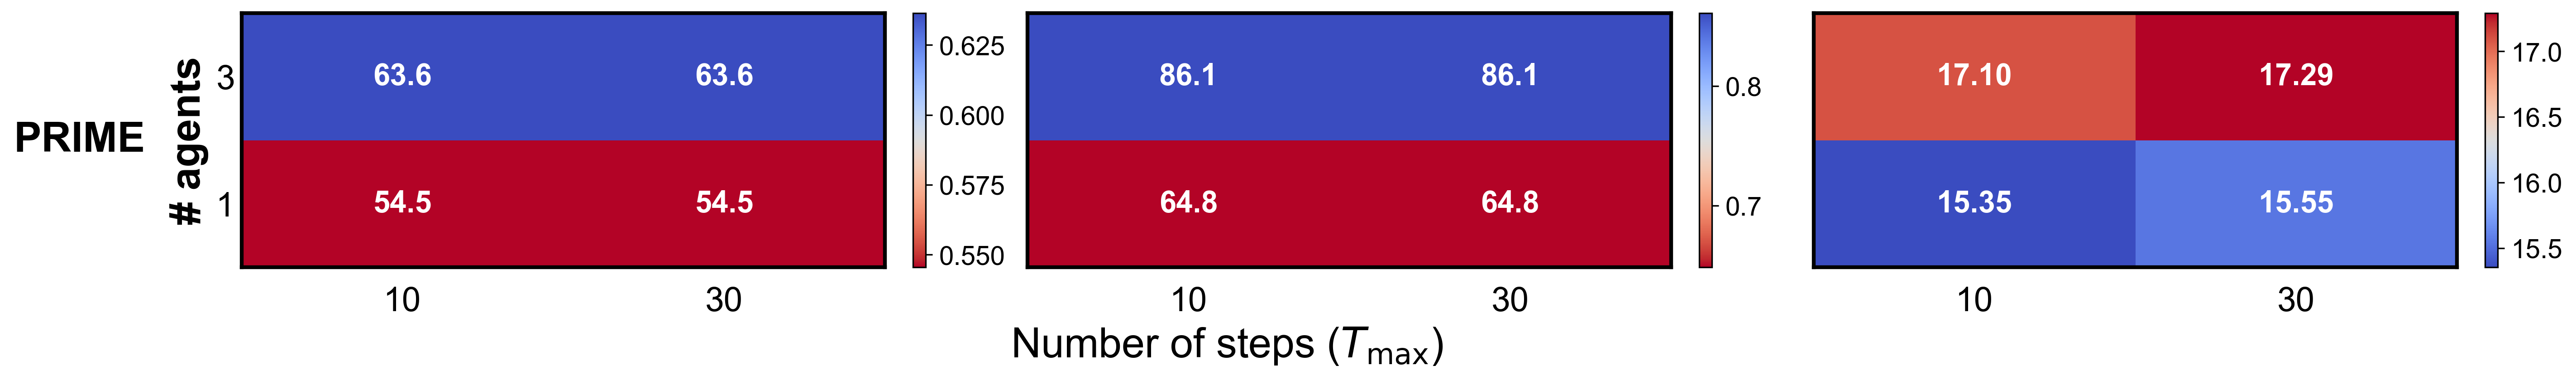

In [3]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

split = "test"
graph_names = ["amazon", "mag", "prime"]
model_name = "graph_explorer_gpt-5.2"

# Hyperparameter grid you care about
num_agents_grid = [1, 3]
t_max_grid = [10, 30]

# -------- make the figure: rows = graphs, cols = metrics --------
fig, axes = plt.subplots(
    len(graph_names),
    3,
    figsize=(20, 7),
    sharex=True,
    sharey=False,
)
# Ensure axes is 2D
if axes.ndim == 1:
    axes = axes[np.newaxis, :]

for row_idx, graph_name in enumerate(graph_names):
    logs_dir = Path(f"../data/experiments/{graph_name}/{model_name}/{split}")
    if not logs_dir.exists():
        # If we don't have this graph, hide the row
        for col in range(3):
            axes[row_idx, col].set_visible(False)
        continue

    json_files = sorted(logs_dir.glob("*.json"), key=lambda f: f.stat().st_ctime)

    # Matrices: rows = num_agents, cols = T_max
    hit1_mat = np.zeros((len(num_agents_grid), len(t_max_grid)))
    recall20_mat = np.zeros((len(num_agents_grid), len(t_max_grid)))
    latency_mat = np.zeros((len(num_agents_grid), len(t_max_grid)))

    for i, n_agents in enumerate(num_agents_grid):
        for j, t_max in enumerate(t_max_grid):
            # One call per coordinate
            df = load_metrics_df(json_files, max_agents=n_agents, max_steps=t_max)

            if len(df) == 0:
                hit1_mat[i, j] = np.nan
                recall20_mat[i, j] = np.nan
                latency_mat[i, j] = np.nan
            else:
                hit1_mat[i, j] = df["hit@1"].mean()
                recall20_mat[i, j] = df["recall@20"].mean()
                latency_mat[i, j] = df["latency"].mean()

    # ---- plot 3 heatmaps for this graph ----
    # Only put metric titles on the top row
    col_titles = ["Hit@1", "Recall@20", "Latency (s)"]
    cbar_labels = ["Hit@1", "Recall@20", "Latency (s)"]
    matrices = [hit1_mat, recall20_mat, latency_mat]

    for col_idx, (matrix, title, cbar_label) in enumerate(
        zip(matrices, col_titles, cbar_labels)
    ):
        ax = axes[row_idx, col_idx]
        invert = cbar_label == "Latency (s)"  # high latency = bad
        format_as_percent = cbar_label != "Latency (s)"

        # Remove plot-level title for cleaner figure
        heatmap_with_numbers(
            ax,
            matrix,
            xticks=t_max_grid,
            yticks=num_agents_grid,
            title="",
            invert=invert,
            format_as_percent=format_as_percent,
        )

        # Only bottom row shows x tick labels
        if row_idx < len(graph_names) - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xticklabels(t_max_grid, fontsize=STYLE['tick_label_fontsize'])

        # Only first column shows y tick labels
        if col_idx > 0:
            ax.set_yticklabels([])
        else:
            ax.set_yticklabels(num_agents_grid, fontsize=STYLE['tick_label_fontsize'])

        # Only first column has y-axis label
        if col_idx == 0:
            ax.set_ylabel("# agents", fontsize=STYLE['axis_label_fontsize'],
                          fontweight=STYLE['axis_label_fontweight'])
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.tick_params(axis='x', pad=10)
        ax.tick_params(axis='both', which='both', length=0)

        # For top row, show metric name above each plot
        if row_idx == 0:
            ax.set_title(title, fontsize=STYLE['title_fontsize'],
                         fontweight=STYLE['title_fontweight'], pad=STYLE['title_pad'])

    # Put graph name as big label on the left of the row
    axes[row_idx, 0].text(
        -0.15,
        0.5,
        graph_name.upper(),
        transform=axes[row_idx, 0].transAxes,
        fontsize=STYLE['axis_label_fontsize'],
        fontweight=STYLE['axis_label_fontweight'],
        va="center",
        ha="right",
    )

# Single shared x-label
fig.text(0.5, 0.01, r"Number of steps ($T_{\max}$)",
         ha='center', fontsize=STYLE['axis_label_fontsize'])

plt.tight_layout(rect=[0.05, 0.03, 1, 0.97])

os.makedirs("../data/figures", exist_ok=True)
plt.savefig(
    "../data/figures/all_graphs_compute_time.pdf",
    dpi=STYLE['fig_dpi'],
    bbox_inches="tight",
)
plt.show()